# 02 — Feature Engineering

This notebook covers Day 2 feature engineering and data preparation:
1. Engineer features from the Vickers dataset
2. Engineer pacing features from Boston Marathon splits
3. Prepare train/test split

**Inputs:** Cleaned Vickers data from `01_data_exploration`, Boston Marathon splits from `data/raw/boston_marathon/`  
**Outputs:** `data/processed/vickers_features.parquet`, `data/processed/train.parquet`, `data/processed/test.parquet`

## Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression

from src.data_loading import load_useable_vickers
from src.baselines import riegel_predict, vdot_from_race, vdot_predict

sns.set_theme(style='whitegrid')
%matplotlib inline

In [5]:
df = load_useable_vickers()

---
## Part 0: Baseline Predictions 

Run Riegel and VDOT on every Vickers runner with a half marathon time, predict their marathon time, and compute error metrics. These numbers are the benchmarks my ML model needs to beat.

### Filter to runners with both half marathon and marathon times

Load useable vickers gives us the useable data from the first notebook. This data only has runners who completed a marathon and also submitted two other races.

### Function to create full predictions

In [44]:
df['riegel_predicted'] = np.nan
df['vdot_predicted'] = np.nan


# selection here impacts error. order prioritizes races in distance decending for that reason.
fallback_order = [
    ('mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

for col, dist in fallback_order:
    mask = df['riegel_predicted'].isna() & df[col].notna()
    df.loc[mask, 'riegel_predicted'] = df.loc[mask, col].apply(
        lambda t: riegel_predict(race_time=t, race_distance=dist, target_distance=26.2)
    )
    df.loc[mask, 'vdot_predicted'] = df.loc[mask, col].apply(
        lambda t: vdot_predict(vdot=vdot_from_race(race_time=t, race_distance=dist), race_distance=26.2)
    )

print(f'Still missing predictions: {df["riegel_predicted"].isna().sum()}')

Still missing predictions: 0


### Error metrics

In [47]:
def mape(y_true, y_pred):
    """Mean absolute percentage error"""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def print_metrics(name, y_true, y_pred):
    """Print MAE, RMSE, MAPE for baseline"""
    print(f'{name}:')
    print(f'  MAE  = {mean_absolute_error(y_true, y_pred):.2f} min')
    print(f'  RMSE = {root_mean_squared_error(y_true, y_pred):.2f} min')
    print(f'  MAPE = {mape(y_true, y_pred):.2f}%')
    print()

In [48]:
actual = df['mf_ti_adj']
print_metrics('Riegel', actual, df['riegel_predicted'])
print_metrics('VDOT', actual, df['vdot_predicted'])

Riegel:
  MAE  = 15.53 min
  RMSE = 20.89 min
  MAPE = 6.53%

VDOT:
  MAE  = 16.18 min
  RMSE = 21.70 min
  MAPE = 6.75%



### Quick visual: predicted vs actual

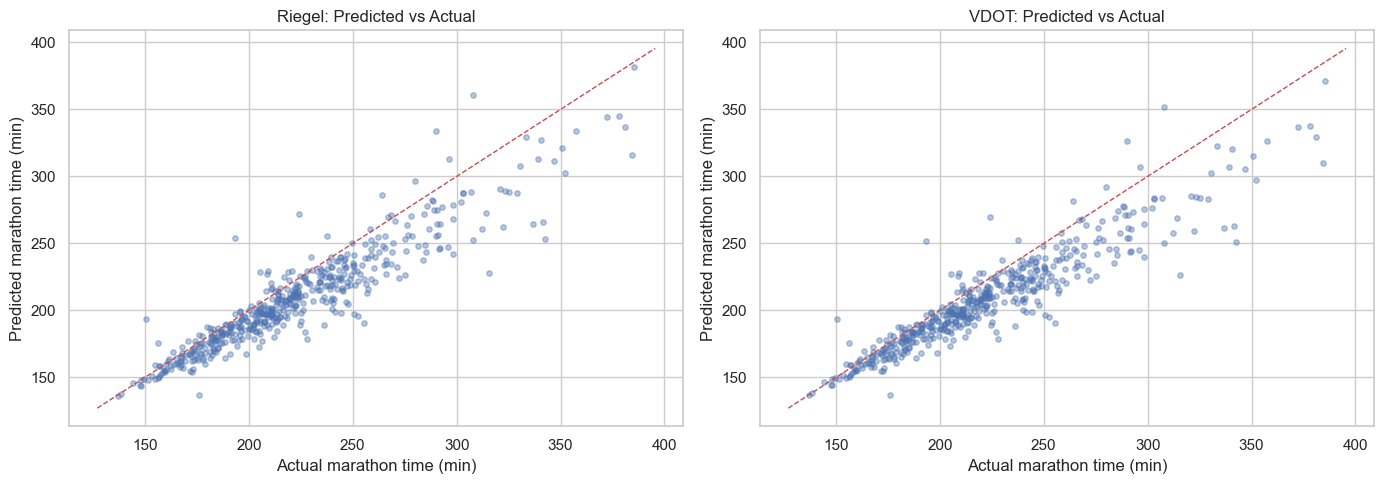

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, col in zip(axes, ['Riegel', 'VDOT'], ['riegel_predicted', 'vdot_predicted']):
    ax.scatter(df['mf_ti_adj'], df[col], alpha=0.4, s=15)
    lims = [df['mf_ti_adj'].min() - 10, df['mf_ti_adj'].max() + 10]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual marathon time (min)')
    ax.set_ylabel('Predicted marathon time (min)')
    ax.set_title(f'{name}: Predicted vs Actual')
plt.tight_layout()
plt.savefig('../results/figures/baseline_predicted_vs_actual.png', dpi=150)

It looks like Riegel and VDOT systematically underpredict marathon times. These graphs are really interesting to me because of how tightly points hug under the line. It almost looks like these predictions act as a lower bound for marathon time, with exceptions increasing as marathoners become more elite. Since many marathoners are using these predictors, I'm thinking this phenomenon could occur because people see the prediction as their time to aim for. This could create a feedback loop where these predictors become self fullfilling. 

Those are ideas to dig into some other time though. What's relevant right now is that both of these predictors systematically underpredict times and that we have metrics for our model to beat.

Riegel:
  MAE  = 15.53 min
  RMSE = 20.89 min
  MAPE = 6.53%

VDOT:
  MAE  = 16.18 min
  RMSE = 21.70 min
  MAPE = 6.75%

These are beatable metrics. MAE of 15:32 minutes for Riegel means that a Riegel prediction could be off your actual pace by a significant amount, enough to totally blow up your pacing. RMSE of 20:53 minutes tells me that there are some runners for whom Riegel predictions were way off their actual time, and significantly more off than the average runner. This is easy to see on the graph. VDOT is slightly worse on all metrics. It's known in the marathon world that VDOT tends to underpredict more aggressively for longer distances than Riegel, so its cool to have actually discovered that on my own.

 MAPE of 6.53% is a good way to conceptualize the issue with these predictions. Nike spent many years and millions of dollars developing a $500 running shoe designed to improve marathon performance by 2%-3%. What's the point of something like that if your pace predictor sets you back more than twice as much?

### Goal Setting

I would be proud of my model got MAE under 10 minutes. I've read some research articles attempting to solve the same problem and they typically acheived 8-12 MAE. Another way to frame it is to aim for < 5% MAPE. I want to acheive these goals while keeping the model generalizeable.

---
## Part 1: Vickers Feature Engineering

Build new features from existing columns using domain knowledge. The goal is to extract information that raw columns don't capture directly.

### Imputed half-marathon

Longer distances will be best at predicting marathon time, so of course I want to use half marathon time as a feature. 106/493 runners are missing half-marathon times. As my dataset is small, and runners who haven't ran a half-marathon are a unique subset of my data I don't want to drop those rows. Instead I'm opting to impute times using Riegel, and put them in a new column. I will not impute times for the other races; I don't want to introduce so much redundant manufactured data into the dataset. It makes sense to do this for the most valuable race, but doing it for all races would just create noise. 

It needs to be noted that this will skew half marathon time faster, as we just saw that Riegel tends to underpredict times. It does feel like there should be a more elegant way to do this, but this is the best I've got right now. Worth learning more about in the future.

In [ ]:
non_hf_races = [
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

df["imputed_mh_ti_adj"] = np.nan

for col, dist in non_hf_races:
    mask = df["mh_ti_adj"].isna() & df[col].notna()
    df.loc[mask, "imputed_mh_ti_adj"] = df.loc[mask, col].apply(
        lambda t: riegel_predict(race_time=t, race_distance=dist, target_distance=13.1)
    )

# merged imputed and actual vals
df["mh_ti_adj_final"] = df["mh_ti_adj"].fillna(df["imputed_mh_ti_adj"])

# only actual vals
# still stored in df["mh_ti_adj"]

# imputed flag
df["mh_ti_adj_imputed_flag"] = df["mh_ti_adj"].isna() & df["imputed_mh_ti_adj"].notna()

print(df["mh_ti_adj_final"])



Missing 0 half-marathons.


Cool, but I want to see how the imputed data looks vs. Our regular half marathon data.

In [104]:
print(round((df["imputed_mh_ti_adj"].mean() - df["mh_ti_adj"].mean()) / df["mh_ti_adj"].mean(), 4))

-0.04


Hm. Imputed half marathons are 4% faster than our actual half marathons. This bugs me. There could be lots of reasons for this. For example, I know that Riegel underpredicts with an MAE of 6.53%. This could also be a faster subset of runners. Or it could be a slower subset of runners, and that's why they are slower than the Riegel underprediction would suggest. 

I could try and do a regression-based imputation, or MICE, but even though this shift is larger than I'd like it to be, it only shifts half-marathon 1% overall, and half marathon is only one feature in my dataset. Although I would like to try this new method and perhaps improve the quality of my dataset, its best for me to stay on track and keep making progress.

### Pace features

Add pace for each race ran by each runner as a feature.

In [84]:
races = [
    ('mh_ti_adj', 13.1),
    ('imputed_mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

for col, dist in races:
    df[f"pace_{col}"] = np.nan

for col, dist in races:
    mask = df[col].notna()
    df.loc[mask, f"pace_{col}"] = df.loc[mask, col].apply(
        lambda t: t / dist
    )


I'm curious what the pace distributions look like in our dataset. Lets take a look.

Neat.

### Endurance ratio

One quirk of running is that the different metabolic aspects of running (power, lactate threshold, endurance, steady-state) is that they don't have 1:1 carry over to eachother when you train them. This is intuitive for most people; you wouldn't expect a 100m trackstar to be better at the marathon than a marathoner, and vice versa. Whats useful about this to us is measuring runner's speed (5k time) against their half marathon time. This gives trainers a picture of how developed different metabolic aspects of running are in a runner, and for our model it will be a useful feature.

In [91]:
# cond_1 = df["k5_ti_adj"].notna() | df["m5_ti_adj"].notna()
# cond_2 = df["m10_ti_adj"].notna() | df["mh_ti_adj"].notna()

# df[cond_1 & cond_2]
df['k5_ti_adj'].notna().sum() / 493

np.float64(0.5780933062880325)

### Speed reserve

Difference between 5K pace and marathon pace — measures how much faster a runner can go at short distances vs long.

### Weekly mileage buckets

Bin weekly mileage into low (<20), medium (20–40), high (40+).

### Interaction terms

Mileage × half marathon pace — captures the combined effect of training volume and current fitness.

### Binary flags

does_intervals, does_tempo_runs — encode training type as 0/1.

### Riegel predicted marathon time as a feature

Use the half marathon time to generate a Riegel prediction. This gives the model the baseline's knowledge for free — the model can then learn the *residual* between Riegel and reality.

### Missing value strategy

*Document your approach here: drop vs impute, and why.*

### Before/after comparison

How do the new features relate to marathon time? Which correlate most strongly?

In [ ]:
# Correlation of new features with marathon time

In [ ]:
# Distribution plots of new features

### Save engineered features

In [ ]:
# df.to_parquet('../data/processed/vickers_features.parquet', index=False)

---
## Part 2: Boston Marathon Splits — Pacing Features

These features describe race *execution*, not training. They can't predict finish time before a race (you don't have splits until after), but they help understand what drives pacing collapse and inform which training features matter.

In [ ]:
# Load Boston Marathon data
# from src.data_loading import load_boston
# boston = load_boston(2017)

### Parse split times

Splits come as strings like "0:24:32" — convert to numeric minutes.

### Pacing features

- First half / second half ratio (positive split metric)
- Pace standard deviation across 5K splits
- Slowdown rate: (last 10K pace) / (first 10K pace)
- "Wall" indicator: did pace slow >20% in the last 10K?

### Summary stats

*What percentage of Boston runners positive-split? By how much on average?*

---
## Part 3: Train/Test Split

Prepare final feature matrix and target variable, then split for modeling.

### Define X and y

In [ ]:
# X = features, y = marathon finish time in minutes
# Drop rows with missing marathon times

### Split

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# print(f'Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows')

### Verify split distributions

Check that train and test sets have similar distributions — we don't want all fast runners in one set.

In [ ]:
# Histogram overlay of train vs test marathon times

### Save

In [ ]:
# Save train/test splits
# train = pd.concat([X_train, y_train], axis=1)
# test = pd.concat([X_test, y_test], axis=1)
# train.to_parquet('../data/processed/train.parquet', index=False)
# test.to_parquet('../data/processed/test.parquet', index=False)

---
## Feature engineering summary

*Which engineered features correlate most strongly with marathon time? Did any surprise you? Any features that seemed promising but turned out uninformative?*